# NREL_multi_task
Schnetで実装、3D構造を入力とする

## データセット読み込み

In [16]:
import sys
import copy
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

from rdkit import Chem
from rdkit import __version__ as rdkit_version
from rdkit.Chem import Draw

import py3Dmol

import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SchNet, global_add_pool

from tqdm import tqdm

import os
import json
from typing import List, Dict, Any, Tuple, Optional, Callable

# ------------------------------
# Reproducibility
# ------------------------------
SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ------------------------------
# Device
# ------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------
# Environment info (for reproducibility)
# ------------------------------
print("===== Environment =====")
print(f"Python           : {sys.version.split()[0]}")
print(f"PyTorch          : {torch.__version__}")
print(f"PyTorch Geometric: {torch_geometric.__version__}")
print(f"RDKit            : {rdkit_version}")
if torch.cuda.is_available():
    print(f"CUDA version     : {torch.version.cuda}")
print("========================")
print("device:", device)

===== Environment =====
Python           : 3.9.23
PyTorch          : 2.2.1+cu121
PyTorch Geometric: 2.6.1
RDKit            : 2025.03.5
CUDA version     : 12.1
device: cuda


In [2]:
# ダウンロードしたデータセットを読み込む
dataset_train = pd.read_csv("../data/NREL/mol_train.csv.gz")
dataset_val = pd.read_csv("../data/NREL/mol_valid.csv.gz")
dataset_test = pd.read_csv("../data/NREL/mol_test.csv.gz")

# 全部くっつける
dataset_full = pd.concat([dataset_train, dataset_val, dataset_test], axis=0)

print("Train dataset size:", len(dataset_train))
print("Validation dataset size:", len(dataset_val))
print("Test dataset size:", len(dataset_test))
print("Full dataset size:", len(dataset_full))

Train dataset size: 84576
Validation dataset size: 5000
Test dataset size: 5000
Full dataset size: 94576


In [3]:
# 目的変数を準備
target_cols = ["gap", "homo", "lumo", "spectral_overlap", "homo_extrapolated", "lumo_extrapolated", "gap_extrapolated", "optical_lumo_extrapolated"]

required_cols = ["mol"] + target_cols
df = dataset_full[required_cols].copy()

for col in target_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=target_cols).reset_index(drop=True)

print("Usable rows:", len(df))
display(df.head(2))

Usable rows: 60404


,mol,gap,homo,lumo,spectral_overlap,homo_extrapolated,lumo_extrapolated,gap_extrapolated,optical_lumo_extrapolated
0,blank\n OpenBabel03101820033D\n\n 53 58 0 0 ...,1.7154,-5.383228,-3.146452,821.664953,-5.044718,-3.193800,1.5668,-3.477918
1,blank\n OpenBabel03101820043D\n\n 58 63 0 0 ...,2.3225,-5.074651,-2.340451,1157.278754,-4.995738,-2.606578,2.0551,-2.940638


In [4]:
# 1行目の mol block を取得
mol_block = df.loc[0, "mol"]

# RDKitで読み込み
mol = Chem.MolFromMolBlock(mol_block, removeHs=False, sanitize=True)

print("mol is None:", mol is None)
if mol is not None:
    print("num atoms:", mol.GetNumAtoms())
    print("num conformers:", mol.GetNumConformers())

mol is None: False
num atoms: 53
num conformers: 1


num conformersが1以上ならSchNetに必要な3D座標は入っている

In [10]:
# ============================================================
# Hold-out split: train / val / test（ランダム分割）
# ============================================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,          # 全体の 20% を val + test に回す
    random_state=SEED,
    shuffle=True,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,          # temp の半分ずつ -> 各 10%
    random_state=SEED,
    shuffle=True,
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(
    "Hold-out split sizes ->",
    "train:", len(train_df),
    "val:", len(val_df),
    "test:", len(test_df),
)

# ============================================================
# Robust scaling: median = 0, IQR = 1（train のみで fit）
# ============================================================

def fit_robust_scaler(y: pd.Series):
    y = y.astype(float)
    med = float(y.median())
    q1 = float(y.quantile(0.25))
    q3 = float(y.quantile(0.75))
    iqr = q3 - q1
    if iqr == 0:
        iqr = 1.0
    return med, iqr

def transform_robust(y: pd.Series, med: float, iqr: float):
    return (y.astype(float) - med) / iqr

def inverse_robust(y_scaled, med: float, iqr: float):
    return y_scaled * iqr + med


# ---- train のみで fit ----
scalers = {col: fit_robust_scaler(train_df[col]) for col in target_cols}

# ---- 各 split に適用（コピーしてから列追加）----
train_df = train_df.copy()
val_df   = val_df.copy()
test_df  = test_df.copy()

for col in target_cols:
    med, iqr = scalers[col]
    train_df[f"{col}_scaled"] = transform_robust(train_df[col], med, iqr)
    val_df[f"{col}_scaled"]   = transform_robust(val_df[col],   med, iqr)
    test_df[f"{col}_scaled"]  = transform_robust(test_df[col],  med, iqr)

# ---- 確認ログ（ターゲット毎）----
for col in target_cols:
    med, iqr = scalers[col]
    q1 = float(train_df[f"{col}_scaled"].quantile(0.25))
    q3 = float(train_df[f"{col}_scaled"].quantile(0.75))
    print(
        f"[fit on train] {col}: median(raw)={med:.5g}, IQR(raw)={iqr:.5g} | "
        f"median(scaled)={float(train_df[f'{col}_scaled'].median()):.5g}, IQR(scaled)={(q3-q1):.5g}"
    )

Hold-out split sizes -> train: 48323 val: 6040 test: 6041
[fit on train] gap: median(raw)=2.3003, IQR(raw)=0.66705 | median(scaled)=0, IQR(scaled)=1
[fit on train] homo: median(raw)=-5.1013, IQR(raw)=0.53334 | median(scaled)=0, IQR(scaled)=1
[fit on train] lumo: median(raw)=-2.5026, IQR(raw)=0.70124 | median(scaled)=0, IQR(scaled)=1
[fit on train] spectral_overlap: median(raw)=2153.1, IQR(raw)=2504.7 | median(scaled)=0, IQR(scaled)=1
[fit on train] homo_extrapolated: median(raw)=-4.7955, IQR(raw)=0.56654 | median(scaled)=0, IQR(scaled)=1
[fit on train] lumo_extrapolated: median(raw)=-2.8975, IQR(raw)=0.60953 | median(scaled)=0, IQR(scaled)=1
[fit on train] gap_extrapolated: median(raw)=1.607, IQR(raw)=0.5527 | median(scaled)=0, IQR(scaled)=1
[fit on train] optical_lumo_extrapolated: median(raw)=-3.1921, IQR(raw)=0.57988 | median(scaled)=0, IQR(scaled)=1


## mol → PyTorch Geometric Data 変換（Dataset作成）
SchNetでは
- x不要
- edge_index不要
- edge_attr不要 

必要なのは
- z : 原子番号
- pos : 3D座標
- y

In [11]:
# ============================================================
# mol block -> PyG Data 変換（SchNet用）
# 入力:
#   z   : atomic number
#   pos : 3D coordinates
#   y   : target values
# ============================================================

from torch.utils.data import Dataset
from rdkit import Chem
import torch
from torch_geometric.data import Data


def molblock_to_schnet_data(mol_block: str, y_values: list):
    """
    mol block 文字列から SchNet 用の PyG Data を作る関数

    Parameters
    ----------
    mol_block : str
        3D座標を含む mol block
    y_values : list
        目的変数のリスト

    Returns
    -------
    Data or None
        PyTorch Geometric の Data オブジェクト
        data.z   : [N]
        data.pos : [N, 3]
        data.y   : [1, T]
    """
    # mol block から RDKit Mol を作成
    mol = Chem.MolFromMolBlock(mol_block, removeHs=False, sanitize=True)

    if mol is None:
        return None

    # conformer が無い場合は除外
    if mol.GetNumConformers() == 0:
        return None

    conf = mol.GetConformer()

    # ----------------------------
    # z : atomic number
    # ----------------------------
    z = torch.tensor(
        [atom.GetAtomicNum() for atom in mol.GetAtoms()],
        dtype=torch.long
    )  # [N]

    # ----------------------------
    # pos : 3D coordinates
    # ----------------------------
    pos = []
    for i in range(mol.GetNumAtoms()):
        p = conf.GetAtomPosition(i)
        pos.append([p.x, p.y, p.z])

    pos = torch.tensor(pos, dtype=torch.float)  # [N, 3]

    # ----------------------------
    # y : targets
    # ----------------------------
    y = torch.tensor(y_values, dtype=torch.float).view(1, -1)  # [1, T]

    # ----------------------------
    # PyG Data
    # ----------------------------
    data = Data(z=z, pos=pos, y=y)

    # 任意で保持
    data.mol_block = mol_block

    return data


class MolBlockSchNetDataset(Dataset):
    """
    DataFrame（mol block + 目的変数）から
    SchNet 用 PyG Data のリストを作る Dataset
    """
    def __init__(
        self,
        df,
        mol_col: str,
        target_cols: list,
        use_scaled: bool = True,
    ):
        self.data_list = []
        bad = 0

        # use_scaled=True なら *_scaled を使う
        y_cols = [f"{c}_scaled" for c in target_cols] if use_scaled else target_cols

        # 必須列チェック
        needed = [mol_col] + y_cols
        missing = [c for c in needed if c not in df.columns]
        if missing:
            raise ValueError(f"df に必要列がありません: {missing}. columns={list(df.columns)}")

        # DataFrame の各行を順に変換
        for _, row in df.iterrows():
            mol_block = row[mol_col]
            y_vals = [row[c] for c in y_cols]

            d = molblock_to_schnet_data(mol_block, y_vals)

            if d is None:
                bad += 1
            else:
                self.data_list.append(d)

        print(f"Converted molecules: {len(self.data_list)} / {len(df)} (invalid removed: {bad})")

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        return self.data_list[idx]

In [12]:
# --- Build datasets ---
train_dataset = MolBlockSchNetDataset(train_df, mol_col="mol", target_cols=target_cols, use_scaled=True)
val_dataset   = MolBlockSchNetDataset(val_df,   mol_col="mol", target_cols=target_cols, use_scaled=True)
test_dataset  = MolBlockSchNetDataset(test_df,  mol_col="mol", target_cols=target_cols, use_scaled=True)

# quick check
d0 = train_dataset[0]
print(d0)
print("z shape:", d0.z.shape)
print("pos shape:", d0.pos.shape)
print("y shape:", d0.y.shape)
print("first 10 z:", d0.z[:10])
print("first atom pos:", d0.pos[0])
print("y:", d0.y)

[20:54:02] Explicit valence for atom # 64 C, 5, is greater than permitted
[20:54:06] Explicit valence for atom # 46 C, 5, is greater than permitted
[20:54:08] Explicit valence for atom # 63 C, 5, is greater than permitted
[20:54:09] Explicit valence for atom # 46 C, 5, is greater than permitted
[20:54:10] Explicit valence for atom # 46 C, 5, is greater than permitted
[20:54:14] Explicit valence for atom # 39 C, 5, is greater than permitted
[20:54:16] Explicit valence for atom # 30 C, 5, is greater than permitted
[20:54:16] Explicit valence for atom # 20 C, 5, is greater than permitted
[20:54:17] Explicit valence for atom # 52 C, 5, is greater than permitted
[20:54:20] Explicit valence for atom # 52 C, 5, is greater than permitted
[20:54:22] Explicit valence for atom # 52 C, 5, is greater than permitted
[20:54:37] Explicit valence for atom # 37 N, 4, is greater than permitted
[20:54:41] Explicit valence for atom # 46 C, 5, is greater than permitted
[20:54:48] Explicit valence for atom #

Converted molecules: 48307 / 48323 (invalid removed: 16)


[20:55:20] Explicit valence for atom # 46 C, 5, is greater than permitted
[20:55:23] Explicit valence for atom # 35 C, 5, is greater than permitted


Converted molecules: 6038 / 6040 (invalid removed: 2)
Converted molecules: 6041 / 6041 (invalid removed: 0)
Data(y=[1, 8], pos=[52, 3], z=[52], mol_block='blank
 OpenBabel03101820463D

 52 56  0  0  0  0  0  0  0  0999 V2000
    7.7496    0.5984    0.3231 C   0  0  0  0  0  0  0  0  0  0  0  0
    7.1417   -0.6184    0.1394 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.7219   -0.5286    0.0546 C   0  0  0  0  0  0  0  0  0  0  0  0
    5.2595    0.7674    0.1777 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.5941    1.8811    0.3991 S   0  0  0  0  0  0  0  0  0  0  0  0
    8.8084    0.7926    0.4137 H   0  0  0  0  0  0  0  0  0  0  0  0
    5.0626   -1.3759   -0.0909 H   0  0  0  0  0  0  0  0  0  0  0  0
    7.2067   -2.9667   -0.1822 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.5020   -3.2060    0.6246 H   0  0  0  0  0  0  0  0  0  0  0  0
    6.6658   -2.9479   -1.1372 H   0  0  0  0  0  0  0  0  0  0  0  0
    8.2414   -4.0772   -0.2463 C   0  0  0  0  0  0  0  0  0  0  0  0
    9

## PyG DataLoaderの作成

In [15]:
# DataLoader + sanity check

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

# 1バッチ取り出して形確認
batch = next(iter(train_loader))
print(batch)

print("batch.z:", batch.z.shape)           # [total_atoms_in_batch]
print("batch.pos:", batch.pos.shape)       # [total_atoms_in_batch, 3]
print("batch.y:", batch.y.shape)           # [num_graphs_in_batch, num_tasks]
print("batch.batch:", batch.batch.shape)   # [total_atoms_in_batch]
print("num_graphs:", batch.num_graphs)

# 明示的に期待shapeを出す
num_tasks = batch.y.size(-1) if batch.y.ndim == 2 else 1
print("inferred num_tasks:", num_tasks)

# 追加チェック
print("max atomic number in batch:", int(batch.z.max()))
print("Any NaN in pos:", torch.isnan(batch.pos).any().item())
print("Any NaN in y  :", torch.isnan(batch.y).any().item())

# GPUに乗せてみる（エラー出ないか確認）
batch = batch.to(device)
print("moved to device OK")

DataBatch(y=[32, 8], pos=[1920, 3], z=[1920], mol_block=[32], batch=[1920], ptr=[33])
batch.z: torch.Size([1920])
batch.pos: torch.Size([1920, 3])
batch.y: torch.Size([32, 8])
batch.batch: torch.Size([1920])
num_graphs: 32
inferred num_tasks: 8
max atomic number in batch: 16
Any NaN in pos: False
Any NaN in y  : False
moved to device OK


## SchNetを定義

In [22]:
from torch_geometric.nn import SchNet, global_mean_pool

class SchNetEncoder(SchNet):
    """
    PyG SchNet の内部 hidden representation を取り出すための拡張版。
    forward() は atom-wise hidden state h を返す。
    """
    def forward(self, z, pos, batch=None):
        assert z.dim() == 1 and z.dtype == torch.long
        assert pos.dim() == 2 and pos.size(-1) == 3

        # 近接グラフ構築
        edge_index, edge_weight = self.interaction_graph(pos, batch)
        edge_attr = self.distance_expansion(edge_weight)

        # atomic embedding
        h = self.embedding(z)

        # interaction blocks
        for interaction in self.interactions:
            h = h + interaction(h, edge_index, edge_weight, edge_attr)

        # ここで止める
        # h: [N_atoms, hidden_channels]
        return h


class SchNetRegressor(nn.Module):
    """
    SchNet encoder + graph pooling + MLP head
    3D構造から multi-target 回帰を行う。
    """
    def __init__(
        self,
        hidden_dim: int = 128,
        num_filters: int = 128,
        num_interactions: int = 6,
        num_gaussians: int = 50,
        cutoff: float = 10.0,
        num_targets: int = 8,
        dropout: float = 0.0,
        pool: str = "mean",   # "mean" or "add"
    ):
        super().__init__()

        self.encoder = SchNetEncoder(
            hidden_channels=hidden_dim,
            num_filters=num_filters,
            num_interactions=num_interactions,
            num_gaussians=num_gaussians,
            cutoff=cutoff,
        )

        self.pool = pool

        self.fc1 = nn.Linear(hidden_dim, 512)
        self.bn1 = nn.BatchNorm1d(512)

        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        self.out = nn.Linear(256, num_targets)

        self.dropout = dropout

    def forward(self, data):
        z = data.z.long()
        pos = data.pos.float()
        batch = data.batch

        # atom-wise hidden representation
        h = self.encoder(z, pos, batch)   # [N_atoms, hidden_dim]

        # graph-level pooling
        if self.pool == "mean":
            g = global_mean_pool(h, batch)   # [B, hidden_dim]
        elif self.pool == "add":
            g = torch_geometric.nn.global_add_pool(h, batch)
        else:
            raise ValueError(f"Unknown pool: {self.pool}")

        x = self.bn1(self.fc1(g))
        x = F.relu(x)
        if self.dropout > 0:
            x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.bn2(self.fc2(x))
        x = F.relu(x)
        if self.dropout > 0:
            x = F.dropout(x, p=self.dropout, training=self.training)

        out = self.out(x)   # [B, num_targets]
        return out

In [ ]:
# 動作確認
model = SchNetRegressor(
    hidden_dim=128,
    num_filters=128,
    num_interactions=6,
    num_gaussians=50,
    cutoff=10.0,
    num_targets=len(target_cols),
    dropout=0.0,
    pool="mean",
).to(device)

batch = next(iter(train_loader)).to(device)
out = model(batch)

print(model)
print("out shape:", out.shape)
print("expected :", (batch.num_graphs, len(target_cols)))

SchNetRegressor(
  (encoder): SchNetEncoder(hidden_channels=128, num_filters=128, num_interactions=6, num_gaussians=50, cutoff=10.0)
  (fc1): Linear(in_features=128, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (out): Linear(in_features=256, out_features=8, bias=True)
)
out shape: torch.Size([32, 8])
expected : (32, 8)


## 学習

In [24]:
# ============================================================
# 損失関数・最適化・学習率スケジューラ
# ============================================================

# マルチタスク回帰なので、全タスク平均の MSE
criterion = nn.MSELoss()

# Adam optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

# 元コード踏襲のごく弱い減衰
decay = 2e-6
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda epoch: (1.0 - decay) ** epoch
)


# ============================================================
# 学習関数
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, device, max_grad_norm=5.0):
    """
    1エポック分の学習

    Returns
    -------
    train_mse : float
        分子あたり平均 MSE（scaled 空間）
    train_mae : float
        分子あたり平均 MAE（scaled 空間）
    """
    model.train()
    total_loss = 0.0
    total_mae = 0.0
    n = 0

    for batch in tqdm(loader, desc="train", leave=False):
        batch = batch.to(device)

        optimizer.zero_grad()

        # 予測
        pred = model(batch)      # [B, T]
        y = batch.y.float()      # [B, T]

        # 損失
        loss = criterion(pred, y)

        # 更新
        loss.backward()

        # gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        optimizer.step()

        # 参考指標
        with torch.no_grad():
            mae = torch.mean(torch.abs(pred - y))

        bsz = batch.num_graphs
        total_loss += loss.item() * bsz
        total_mae  += mae.item() * bsz
        n += bsz

    return total_loss / n, total_mae / n


@torch.no_grad()
def evaluate_scaled(model, loader, device, target_cols):
    """
    scaled 空間での評価

    Returns
    -------
    results : dict
        {
          target_name: {"mae":..., "rmse":..., "r2":...},
          "_macro": {...}
        }
    """
    model.eval()
    preds, ys = [], []

    for batch in tqdm(loader, desc="eval_scaled", leave=False):
        batch = batch.to(device)
        pred = model(batch).cpu()
        y = batch.y.cpu()
        preds.append(pred)
        ys.append(y)

    preds = torch.cat(preds, dim=0)   # [N, T]
    ys    = torch.cat(ys, dim=0)      # [N, T]

    results = {}
    for i, col in enumerate(target_cols):
        resid = preds[:, i] - ys[:, i]

        mae = resid.abs().mean().item()
        rmse = torch.sqrt((resid ** 2).mean()).item()

        y_mean = ys[:, i].mean()
        ss_tot = torch.sum((ys[:, i] - y_mean) ** 2)
        ss_res = torch.sum(resid ** 2)
        r2 = (1.0 - ss_res / (ss_tot + 1e-12)).item()

        results[col] = {"mae": mae, "rmse": rmse, "r2": r2}

    results["_macro"] = {
        "mae": float(np.mean([results[c]["mae"] for c in target_cols])),
        "rmse": float(np.mean([results[c]["rmse"] for c in target_cols])),
        "r2": float(np.mean([results[c]["r2"] for c in target_cols])),
    }

    return results


@torch.no_grad()
def evaluate_raw(model, loader, device, target_cols, scalers):
    """
    raw 空間（robust scaling を逆変換）での評価
    """
    model.eval()
    preds, ys = [], []

    for batch in tqdm(loader, desc="eval_raw", leave=False):
        batch = batch.to(device)
        pred = model(batch).cpu()   # scaled
        y = batch.y.cpu()           # scaled
        preds.append(pred)
        ys.append(y)

    preds = torch.cat(preds, dim=0)
    ys    = torch.cat(ys, dim=0)

    results = {}
    for i, col in enumerate(target_cols):
        med, iqr = scalers[col]

        pred_raw = preds[:, i] * iqr + med
        y_raw    = ys[:, i] * iqr + med

        resid = pred_raw - y_raw
        mae = resid.abs().mean().item()
        rmse = torch.sqrt((resid ** 2).mean()).item()

        y_mean = y_raw.mean()
        ss_tot = torch.sum((y_raw - y_mean) ** 2)
        ss_res = torch.sum(resid ** 2)
        r2 = (1.0 - ss_res / (ss_tot + 1e-12)).item()

        results[col] = {"mae": mae, "rmse": rmse, "r2": r2}

    results["_macro"] = {
        "mae": float(np.mean([results[c]["mae"] for c in target_cols])),
        "rmse": float(np.mean([results[c]["rmse"] for c in target_cols])),
        "r2": float(np.mean([results[c]["r2"] for c in target_cols])),
    }

    return results


def results_to_df(results: dict, title: str):
    """
    評価結果を DataFrame にまとめる
    """
    dfm = pd.DataFrame(results).T
    dfm.index.name = "target"
    dfm = dfm[["mae", "rmse", "r2"]]
    print(f"\n[{title}]")
    print(dfm)
    return dfm

### NOTE:
- SchNet は 3D座標ベースで表現力が高いため、GCNより学習が不安定になる場合がある。
- そのため軽い weight decay と gradient clipping を追加している。

In [25]:
# ============================================================
# 学習ループ
# ============================================================

max_epochs = 500
patience = 20

# 全体平均で early stopping
monitor_col = "_macro"
monitor_key = "rmse"   # "rmse" or "mae"

best_metric = float("inf")
best_state = None
best_epoch = None
bad_epochs = 0

history = []

# ログ表示用
show_cols = target_cols[:3] if len(target_cols) >= 3 else target_cols

for epoch in range(1, max_epochs + 1):

    # ----------------------------
    # 1) Train
    # ----------------------------
    train_mse, train_mae = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    # NaN/Inf guard
    if not np.isfinite(train_mse) or not np.isfinite(train_mae):
        raise RuntimeError(
            f"NaN or Inf detected in training metrics: train_mse={train_mse}, train_mae={train_mae}"
        )

    # ----------------------------
    # 2) Validation (scaled)
    # ----------------------------
    val_scaled = evaluate_scaled(
        model, val_loader, device, target_cols
    )

    if monitor_col not in val_scaled:
        raise KeyError(
            f"monitor_col='{monitor_col}' が val_scaled にありません: keys={list(val_scaled.keys())}"
        )

    current = val_scaled[monitor_col][monitor_key]

    if not np.isfinite(current):
        raise RuntimeError(
            f"NaN or Inf detected in validation metric: {monitor_col}_{monitor_key}={current}"
        )

    # ----------------------------
    # 3) Scheduler step
    # ----------------------------
    scheduler.step()
    lr = optimizer.param_groups[0]["lr"]

    # ----------------------------
    # 4) Log 出力
    # ----------------------------
    macro = val_scaled["_macro"]
    parts = [
        f"[Epoch {epoch:03d}] lr={lr:.2e}",
        f"train_MSE={train_mse:.4f} train_MAE={train_mae:.4f}",
        f"VAL_macro_RMSE={macro['rmse']:.4f} macro_MAE={macro['mae']:.4f} macro_R2={macro['r2']:.4f}",
    ]
    for c in show_cols:
        r = val_scaled[c]
        parts.append(
            f"VAL {c}_RMSE={r['rmse']:.4f} {c}_MAE={r['mae']:.4f} {c}_R2={r['r2']:.4f}"
        )
    print(" | ".join(parts))

    # ----------------------------
    # 5) history 保存
    # ----------------------------
    row = {
        "epoch": epoch,
        "lr": lr,
        "train_mse": train_mse,
        "train_mae": train_mae,
        f"val_{monitor_col}_{monitor_key}": current,
        "val_macro_rmse": macro["rmse"],
        "val_macro_mae": macro["mae"],
        "val_macro_r2": macro["r2"],
    }
    for c in target_cols:
        row[f"val_{c}_rmse"] = val_scaled[c]["rmse"]
        row[f"val_{c}_mae"] = val_scaled[c]["mae"]
        row[f"val_{c}_r2"] = val_scaled[c]["r2"]
    history.append(row)

    # ----------------------------
    # 6) Early stopping
    # ----------------------------
    if current < best_metric - 1e-6:
        best_metric = current
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(
                f"Early stopping triggered (patience={patience}). "
                f"Best epoch={best_epoch}, "
                f"Best VAL {monitor_col}_{monitor_key}={best_metric:.4f}"
            )
            break


# ============================================================
# 最良モデル復元
# ============================================================

if best_state is not None:
    model.load_state_dict(best_state)

model.to(device).eval()

# 復元後に Validation を再評価
val_scaled_best = evaluate_scaled(model, val_loader, device, target_cols)

print("\n===== BEST MODEL: VAL (scaled) =====")
print(f"best_epoch: {best_epoch}")
print(
    f"monitor: {monitor_col}_{monitor_key} = "
    f"{val_scaled_best[monitor_col][monitor_key]:.4f}"
)


# ============================================================
# TEST 評価
# ============================================================

test_scaled = evaluate_scaled(model, test_loader, device, target_cols)
test_raw    = evaluate_raw(model, test_loader, device, target_cols, scalers)

print("\n===== FINAL TEST (scaled space) =====")
for k in (["_macro"] + show_cols):
    print(k, test_scaled[k])

print("\n===== FINAL TEST (raw space) =====")
for k in (["_macro"] + show_cols):
    print(k, test_raw[k])

test_scaled_df = results_to_df(test_scaled, "TEST scaled metrics")
test_raw_df    = results_to_df(test_raw,    "TEST raw metrics")

history_df = pd.DataFrame(history)
display(history_df.head())

[Epoch 001] lr=1.00e-03 | train_MSE=0.1462 train_MAE=0.2839 | VAL_macro_RMSE=0.2774 macro_MAE=0.2062 macro_R2=0.8786 | VAL gap_RMSE=0.2874 gap_MAE=0.2187 gap_R2=0.8624 | VAL homo_RMSE=0.2555 homo_MAE=0.1878 homo_R2=0.8977 | VAL lumo_RMSE=0.2326 lumo_MAE=0.1767 lumo_R2=0.9137


[Epoch 002] lr=1.00e-03 | train_MSE=0.0872 train_MAE=0.2204 | VAL_macro_RMSE=0.2592 macro_MAE=0.1942 macro_R2=0.8933 | VAL gap_RMSE=0.2609 gap_MAE=0.1936 gap_R2=0.8866 | VAL homo_RMSE=0.2585 homo_MAE=0.2033 homo_R2=0.8953 | VAL lumo_RMSE=0.2098 lumo_MAE=0.1566 lumo_R2=0.9298


[Epoch 003] lr=1.00e-03 | train_MSE=0.0732 train_MAE=0.2021 | VAL_macro_RMSE=0.2352 macro_MAE=0.1751 macro_R2=0.9121 | VAL gap_RMSE=0.2333 gap_MAE=0.1796 gap_R2=0.9093 | VAL homo_RMSE=0.1903 homo_MAE=0.1424 homo_R2=0.9433 | VAL lumo_RMSE=0.1936 lumo_MAE=0.1447 lumo_R2=0.9402


[Epoch 004] lr=1.00e-03 | train_MSE=0.0654 train_MAE=0.1913 | VAL_macro_RMSE=0.2594 macro_MAE=0.1956 macro_R2=0.8902 | VAL gap_RMSE=0.3540 gap_MAE=0.2889 gap_R2=0.7912 | VAL homo_RMSE=0.2116 homo_MAE=0.1642 homo_R2=0.9298 | VAL lumo_RMSE=0.2554 lumo_MAE=0.1974 lumo_R2=0.8960


[Epoch 005] lr=1.00e-03 | train_MSE=0.0590 train_MAE=0.1817 | VAL_macro_RMSE=0.2074 macro_MAE=0.1518 macro_R2=0.9319 | VAL gap_RMSE=0.2163 gap_MAE=0.1631 gap_R2=0.9221 | VAL homo_RMSE=0.1862 homo_MAE=0.1368 homo_R2=0.9457 | VAL lumo_RMSE=0.1707 lumo_MAE=0.1314 lumo_R2=0.9535


...

[Epoch 122] lr=1.00e-03 | train_MSE=0.0201 train_MAE=0.1045 | VAL_macro_RMSE=0.1556 macro_MAE=0.1076 macro_R2=0.9611 | VAL gap_RMSE=0.1448 gap_MAE=0.1031 gap_R2=0.9651 | VAL homo_RMSE=0.1452 homo_MAE=0.0921 homo_R2=0.9670 | VAL lumo_RMSE=0.1135 lumo_MAE=0.0854 lumo_R2=0.9794


[Epoch 123] lr=1.00e-03 | train_MSE=0.0204 train_MAE=0.1051 | VAL_macro_RMSE=0.1635 macro_MAE=0.1158 macro_R2=0.9570 | VAL gap_RMSE=0.1402 gap_MAE=0.1003 gap_R2=0.9673 | VAL homo_RMSE=0.1228 homo_MAE=0.0896 homo_R2=0.9764 | VAL lumo_RMSE=0.1295 lumo_MAE=0.0959 lumo_R2=0.9732
Early stopping triggered (patience=20). Best epoch=103, Best VAL _macro_rmse=0.1379



===== BEST MODEL: VAL (scaled) =====
best_epoch: 103
monitor: _macro_rmse = 0.1379



===== FINAL TEST (scaled space) =====
_macro {'mae': 0.09696052595973015, 'rmse': 0.1363433040678501, 'r2': 0.9708257913589478}
gap {'mae': 0.08602044731378555, 'rmse': 0.11993154138326645, 'r2': 0.9764289855957031}
homo {'mae': 0.09025091677904129, 'rmse': 0.1253701001405716, 'r2': 0.976739227771759}
lumo {'mae': 0.07597599923610687, 'rmse': 0.10186295211315155, 'r2': 0.9842771887779236}

===== FINAL TEST (raw space) =====
_macro {'mae': 23.17025822447613, 'rmse': 32.83648537658155, 'r2': 0.9708257913589478}
gap {'mae': 0.05737994238734245, 'rmse': 0.08000033348798752, 'r2': 0.9764289855957031}
homo {'mae': 0.048134706914424896, 'rmse': 0.06686528027057648, 'r2': 0.976739227771759}
lumo {'mae': 0.053277209401130676, 'rmse': 0.07143010944128036, 'r2': 0.9842771887779236}

[TEST scaled metrics]
                                mae      rmse        r2
target                                                 
gap                        0.086020  0.119932  0.976429
homo                      

,epoch,lr,train_mse,train_mae,val__macro_rmse,val_macro_rmse,val_macro_mae,val_macro_r2,val_gap_rmse,val_gap_mae,...,val_homo_extrapolated_r2,val_lumo_extrapolated_rmse,val_lumo_extrapolated_mae,val_lumo_extrapolated_r2,val_gap_extrapolated_rmse,val_gap_extrapolated_mae,val_gap_extrapolated_r2,val_optical_lumo_extrapolated_rmse,val_optical_lumo_extrapolated_mae,val_optical_lumo_extrapolated_r2
0,1,0.001,0.146206,0.283913,0.277382,0.277382,0.206175,0.878620,0.287387,0.218658,...,0.886845,0.262839,0.192984,0.899495,0.333581,0.244777,0.812897,0.265354,0.200210,0.897982
1,2,0.001,0.087229,0.220437,0.259244,0.259244,0.194237,0.893268,0.260887,0.193597,...,0.880744,0.245463,0.177813,0.912344,0.333160,0.248487,0.813370,0.243281,0.181490,0.914249
2,3,0.001,0.073179,0.202061,0.235229,0.235229,0.175059,0.912061,0.233319,0.179563,...,0.918543,0.260294,0.190814,0.901432,0.304142,0.223679,0.844464,0.244243,0.180792,0.913569
3,4,0.001,0.065417,0.191325,0.259405,0.259405,0.195608,0.890164,0.354037,0.288912,...,0.935542,0.224741,0.161780,0.926520,0.297020,0.221031,0.851664,0.228551,0.170522,0.924319
4,5,0.001,0.059030,0.181724,0.207380,0.207380,0.151814,0.931926,0.216288,0.163058,...,0.936930,0.212449,0.154088,0.934337,0.262262,0.185747,0.884350,0.203523,0.150486,0.939986


In [26]:
# 可視化用ユーティリティ関数
@torch.no_grad()
def predict_on_loader(model, loader, device, desc=None):
    """
    Returns:
      pred:  [N_graphs, T]
      true:  [N_graphs, T]
      smiles: list[str] length N_graphs
    """
    model.eval()
    all_pred = []
    all_true = []
    all_smiles = []

    it = loader
    if desc is not None:
        it = tqdm(loader, desc=desc, leave=False)

    for batch in it:
        batch = batch.to(device)

        pred = model(batch)              # [B, T]
        y = batch.y.float()              # [B, T]

        all_pred.append(pred.detach().cpu())
        all_true.append(y.detach().cpu())

        # batch.smiles は DataLoader によって list になっている想定
        if hasattr(batch, "smiles"):
            all_smiles.extend(list(batch.smiles))
        else:
            all_smiles.extend([""] * int(batch.num_graphs))

    pred = torch.cat(all_pred, dim=0)    # [N, T]
    true = torch.cat(all_true, dim=0)    # [N, T]

    # 整合チェック
    n = true.shape[0]
    if len(all_smiles) != n:
        all_smiles = all_smiles[:n]

    return pred, true, all_smiles

@torch.no_grad()
def regression_metrics_torch(y_true: torch.Tensor, y_pred: torch.Tensor):
    """
    1つのターゲットに対して回帰指標（MAE / RMSE / R^2）を計算する。

    Parameters
    ----------
    y_true : torch.Tensor, shape [N]
        正解値（CPUテンソル想定。GPUでも動くが最後に .item() するためCPU推奨）
    y_pred : torch.Tensor, shape [N]
        予測値

    Returns
    -------
    mae : float
    rmse: float
    r2  : float
    """
    # 念のため float 化（学習で float を使っていても型が混ざることがあるため）
    y_true = y_true.float()
    y_pred = y_pred.float()

    resid = y_pred - y_true

    # 平均絶対誤差（MAE）
    mae = resid.abs().mean().item()

    # 二乗平均平方根誤差（RMSE）
    rmse = torch.sqrt((resid ** 2).mean()).item()

    # 決定係数（R^2）
    # R^2 = 1 - SS_res / SS_tot
    y_mean = y_true.mean()
    ss_tot = torch.sum((y_true - y_mean) ** 2)
    ss_res = torch.sum(resid ** 2)
    r2 = (1.0 - ss_res / (ss_tot + 1e-12)).item()

    return mae, rmse, r2

def inverse_robust_torch(y_scaled: torch.Tensor, med: float, iqr: float):
    """
    robust scaling の逆変換（scaled -> raw）を行う。

    robust scaling: y_scaled = (y - med) / iqr
    inverse       : y = y_scaled * iqr + med
    """
    return y_scaled * float(iqr) + float(med)

@torch.no_grad()
def metrics_1task(true_2d: torch.Tensor, pred_2d: torch.Tensor, task_idx: int):
    """
    true_2d, pred_2d: [N, T]
    Returns: (mae, rmse, r2) as floats
    """
    y = true_2d[:, task_idx].detach().cpu().float()
    p = pred_2d[:, task_idx].detach().cpu().float()

    resid = p - y
    mae = resid.abs().mean().item()
    rmse = torch.sqrt((resid ** 2).mean()).item()

    y_mean = y.mean()
    ss_tot = torch.sum((y - y_mean) ** 2)
    ss_res = torch.sum(resid ** 2)
    r2 = (1.0 - ss_res / (ss_tot + 1e-12)).item()

    return mae, rmse, r2

@torch.no_grad()
def metrics_1task_raw(true_2d: torch.Tensor, pred_2d: torch.Tensor, task_idx: int, med: float, iqr: float):
    y_s = true_2d[:, task_idx].detach().cpu().float()
    p_s = pred_2d[:, task_idx].detach().cpu().float()

    y = inverse_robust_torch(y_s, med, iqr)
    p = inverse_robust_torch(p_s, med, iqr)

    return regression_metrics_torch(y, p)  # (mae, rmse, r2) in raw

def plot_parity_train_val_1task(
    true_tr_2d: torch.Tensor, pred_tr_2d: torch.Tensor,
    true_va_2d: torch.Tensor, pred_va_2d: torch.Tensor,
    target_name: str, task_idx: int,
    title: str,
    med: float, iqr: float,
    max_points: int = 20000,
):
    # --- extract (scaled) ---
    tr_true_s = true_tr_2d[:, task_idx].detach().cpu().float().view(-1)
    tr_pred_s = pred_tr_2d[:, task_idx].detach().cpu().float().view(-1)
    va_true_s = true_va_2d[:, task_idx].detach().cpu().float().view(-1)
    va_pred_s = pred_va_2d[:, task_idx].detach().cpu().float().view(-1)

    # --- inverse robust -> raw ---
    tr_true = inverse_robust_torch(tr_true_s, med, iqr)
    tr_pred = inverse_robust_torch(tr_pred_s, med, iqr)
    va_true = inverse_robust_torch(va_true_s, med, iqr)
    va_pred = inverse_robust_torch(va_pred_s, med, iqr)

    # --- subsample (independently) ---
    n_tr = tr_true.numel()
    if n_tr > max_points:
        idx = torch.randperm(n_tr)[:max_points]
        tr_true, tr_pred = tr_true[idx], tr_pred[idx]

    n_va = va_true.numel()
    if n_va > max_points:
        idx = torch.randperm(n_va)[:max_points]
        va_true, va_pred = va_true[idx], va_pred[idx]

    # --- metrics for legend (RAW, use full tensors) ---
    tr_mae, tr_rmse, tr_r2 = metrics_1task_raw(true_tr_2d, pred_tr_2d, task_idx, med, iqr)
    va_mae, va_rmse, va_r2 = metrics_1task_raw(true_va_2d, pred_va_2d, task_idx, med, iqr)

    # --- plotting as lists ---
    x_tr, y_tr = tr_true.tolist(), tr_pred.tolist()
    x_va, y_va = va_true.tolist(), va_pred.tolist()

    # min/max for diagonal in RAW space
    mn = min(min(x_tr), min(y_tr), min(x_va), min(y_va))
    mx = max(max(x_tr), max(y_tr), max(x_va), max(y_va))

    # unit label (optional)
    unit = "nm" if "nm" in target_name else ("ns" if "ns" in target_name else "")
    xlabel = f"True {target_name} ({unit})" if unit else f"True {target_name} (raw)"
    ylabel = f"Pred {target_name} ({unit})" if unit else f"Pred {target_name} (raw)"

    plt.figure()
    plt.scatter(x_tr, y_tr, s=8,
                label=f"train  MAE={tr_mae:.3f} RMSE={tr_rmse:.3f} R2={tr_r2:.3f}")
    plt.scatter(x_va, y_va, s=8,
                label=f"val    MAE={va_mae:.3f} RMSE={va_rmse:.3f} R2={va_r2:.3f}")
    plt.plot([mn, mx], [mn, mx])

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.show()

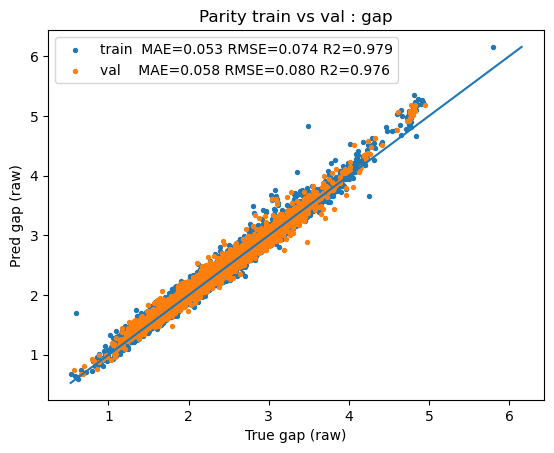

In [27]:
pred_tr, true_tr, smi_tr = predict_on_loader(model, train_loader, device, desc="predict(train)")
pred_va, true_va, smi_va = predict_on_loader(model, val_loader,   device, desc="predict(val)")
pred_te, true_te, smi_te = predict_on_loader(model, test_loader,  device, desc="predict(test)")

task_name = target_cols[0]           # example: first target
task_idx = target_cols.index(task_name)

med, iqr = scalers[task_name]

plot_parity_train_val_1task(true_tr, pred_tr,
                            true_va, pred_va,
                            task_name,
                            task_idx,
                            title=f"Parity train vs val : {task_name}",
                            max_points=20000,
                            med=med, iqr=iqr)

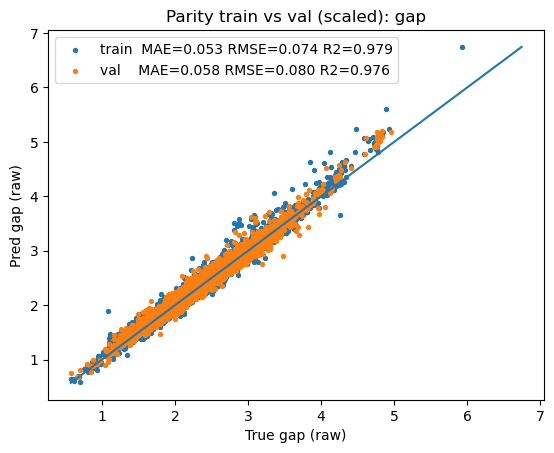

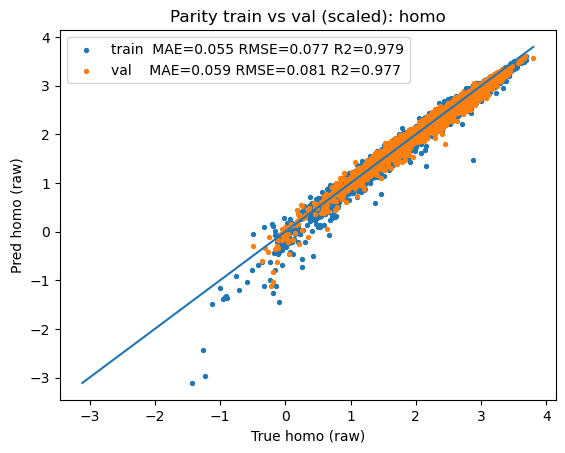

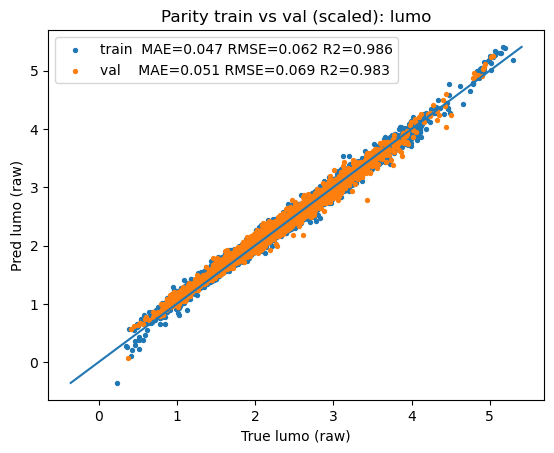

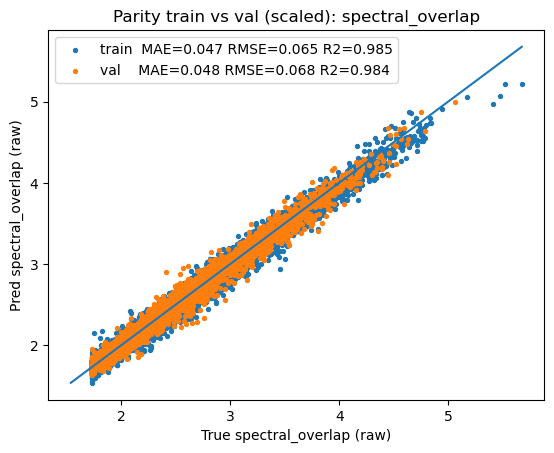

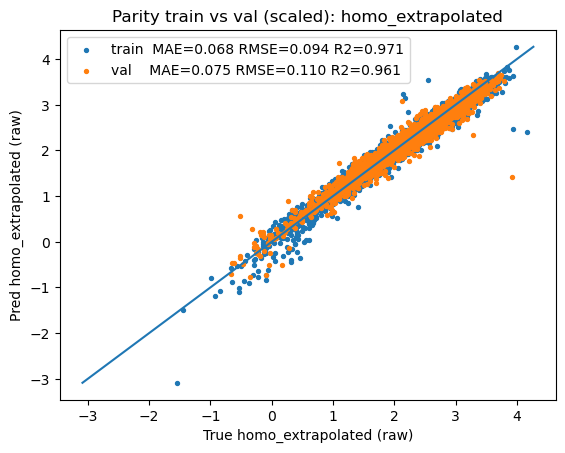

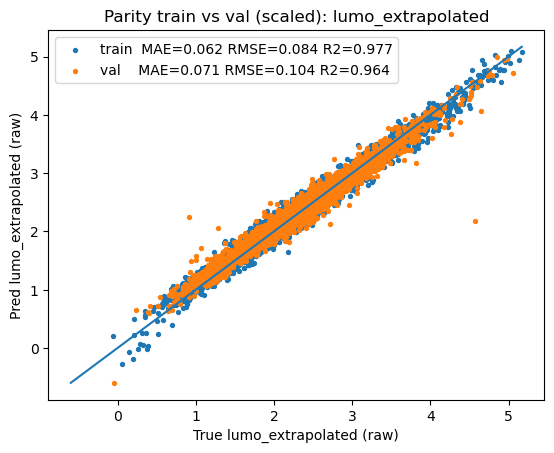

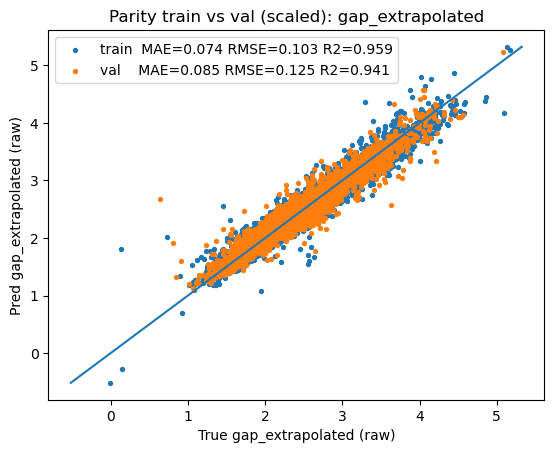

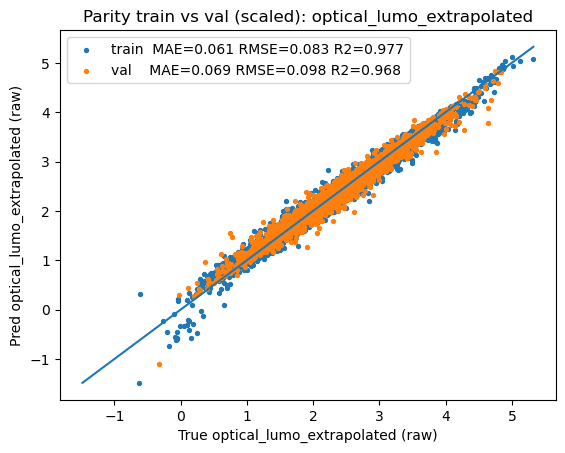

In [28]:
for task_name in target_cols:
    task_idx = target_cols.index(task_name)
    plot_parity_train_val_1task(true_tr, pred_tr, true_va, pred_va,
                                task_name, task_idx,
                                title=f"Parity train vs val (scaled): {task_name}",
                                max_points=20000,
                                med=med,
                                iqr=iqr)